The next technical step in the Machine Learning pipeline is Feature Engineering, which defines your target variable and creates the time-series features needed for prediction.
 3. Feature Engineering: 
  Define Target and Create Time-Series FeaturesThis step prepares your data for the model by:Defining the Target Variable 
  ($\mathbf{Y}$): 
  We'll use the next day's scaled 24-hour volume as a proxy for future liquidity.Creating Features
   ($\mathbf{X}$): We'll use the current day's data (which is the previous day relative to the target) to predict the future.

In [23]:
# --- 3. Feature Engineering: Define Target and Create Time-Series Features ---

# Load the preprocessed data (which is already clean and scaled)
df_processed = pd.read_csv('cryptocurrency_preprocessed.csv')

# Ensure the 'date' column is datetime and data is sorted by coin and date for correct lagging
df_processed['date'] = pd.to_datetime(df_processed['date'])
df_processed = df_processed.sort_values(by=['symbol', 'date']).reset_index(drop=True)

# Define the numerical columns used to create the target variable
target_col = '24h_volume'

# 1. Define the Target Variable (Y)
# Target: The NEXT day's 24h_volume (our proxy for future liquidity/market activity).
# We use .shift(-1) to bring the next day's volume onto the current day's row.
df_processed['target_liquidity_volume'] = df_processed.groupby('symbol')[target_col].shift(-1)


# 2. Final Cleaning for ML Preparation
# Drop the original date/coin columns which aren't features
df_ml = df_processed.drop(columns=['date', 'coin'])

# Drop rows where the target is NaN (the last day entry for each coin)
# These rows cannot be used for training as they lack a future value to predict.
df_ml.dropna(inplace=True)

# Separate features (X) and target (Y)
X = df_ml.drop(columns=['target_liquidity_volume', 'symbol']) # 'symbol' is categorical, drop for now
Y = df_ml['target_liquidity_volume']

print("\n--- ML-Ready Feature Set (X) Head ---")
print(X.head())

print(f"\nFinal Feature Matrix shape (X): {X.shape}")
print(f"Final Target Vector shape (Y): {Y.shape}")

# Save the final ML-ready dataset
df_ml.to_csv('cryptocurrency_ml_ready.csv', index=False)


--- ML-Ready Feature Set (X) Head ---
      price        1h       24h        7d  24h_volume   mkt_cap
0 -0.142461  0.233622  0.106045  1.794181   -0.103653 -0.091165
2 -0.142853  0.419995  1.477408  0.609464   -0.061100 -0.082569
4 -0.113187  1.016388  1.816017  0.460828   -0.002423 -0.049797
6 -0.142941  0.941839 -0.029398 -0.024425   -0.099950 -0.095077
8 -0.143172  0.308171  0.190697 -0.116229   -0.101373 -0.094404

Final Feature Matrix shape (X): (497, 6)
Final Target Vector shape (Y): (497,)


 Exploratory Data Analysis (EDA)

--- Correlation with Target Variable (Liquidity) ---
target_liquidity_volume    1.000000
24h_volume                 0.992950
mkt_cap                    0.559324
price                      0.155249
7d                         0.016871
24h                       -0.005831
1h                        -0.047206
Name: target_liquidity_volume, dtype: float64


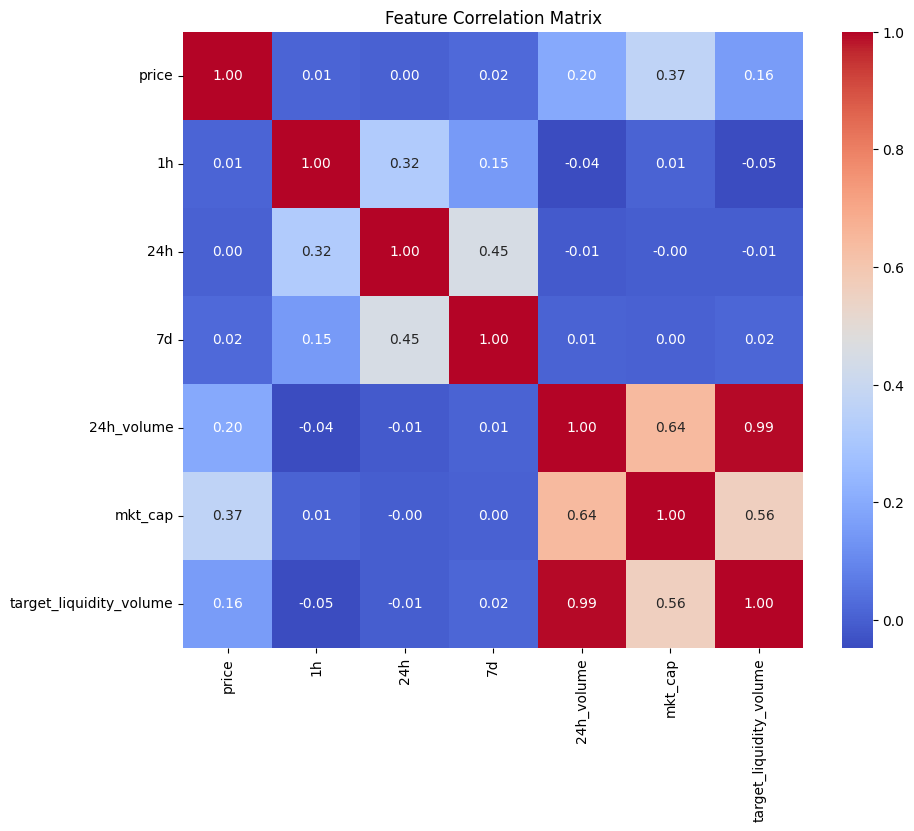

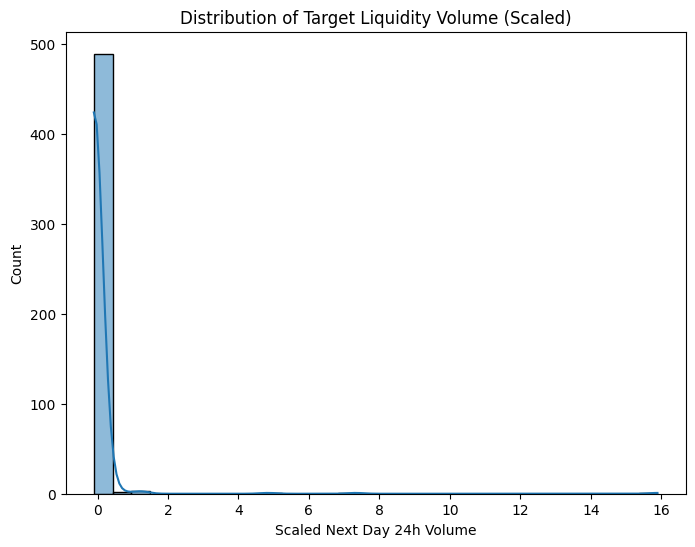

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the ML-Ready data from the previous step
df_ml = pd.read_csv('cryptocurrency_ml_ready.csv')

# --- 1. Correlation Analysis ---
print("--- Correlation with Target Variable (Liquidity) ---")

# Select only columns that are of a numeric type for correlation
df_numeric = df_ml.select_dtypes(include=np.number)
correlation_matrix = df_numeric.corr()

# Get correlation of all features with the target
target_corr = correlation_matrix['target_liquidity_volume'].sort_values(ascending=False)
print(target_corr)

# Visualize the correlation matrix (Heatmap)
plt.figure(figsize=(10, 8))
# 
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix')
plt.savefig('correlation_heatmap.png')
plt.show()

# --- 2. Distribution Analysis of the Target Variable ---
plt.figure(figsize=(8, 6))
sns.histplot(df_numeric['target_liquidity_volume'], kde=True, bins=30)
plt.title('Distribution of Target Liquidity Volume (Scaled)')
plt.xlabel('Scaled Next Day 24h Volume')
plt.savefig('target_distribution.png')
plt.show()

6. Model Training: Train the selected model using the processed dataset 
7. Model Evaluation: Assess model performance using metrics such as RMSE, MAE, and R² score.


Training set size: 397 rows
Testing set size: 100 rows

Training Random Forest Regressor...
Training Complete.

--- Model Evaluation ---
Mean Squared Error (MSE): 1.5672
Root Mean Squared Error (RMSE): 1.2519
R-squared (R2) Score: 0.3869

--- Top 5 Feature Importances ---
24h_volume    0.578193
mkt_cap       0.371122
price         0.032979
7d            0.007807
24h           0.005740
dtype: float64


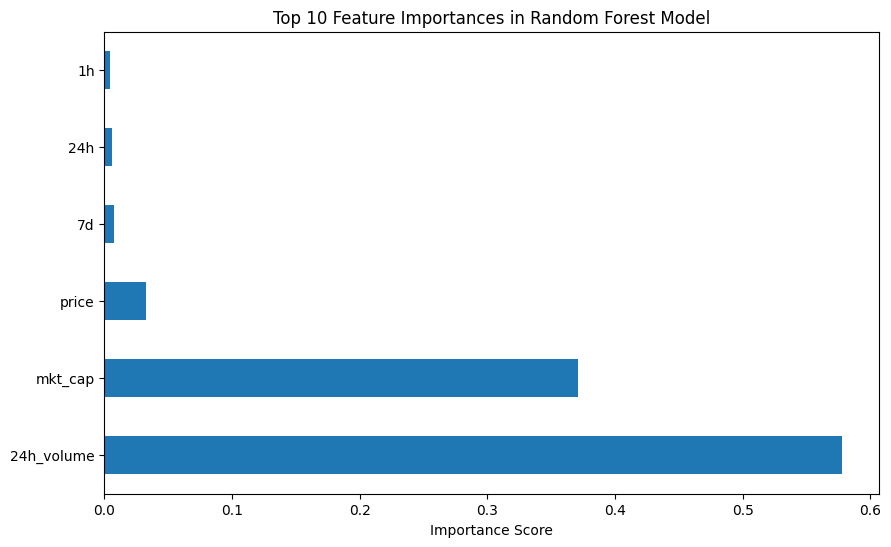

In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Load the final ML-Ready data from Step 3 (Feature Engineering)
df_ml = pd.read_csv('cryptocurrency_ml_ready.csv')

# Separate Features (X) and Target (Y)
# The 'symbol' column is excluded as it is a categorical identifier
X = df_ml.drop(columns=['symbol', 'target_liquidity_volume'])
Y = df_ml['target_liquidity_volume']

# 1. Split Data into Training and Testing Sets (80% Train, 20% Test)
# Using a fixed random_state ensures reproducibility
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

print(f"\nTraining set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

# 2. Initialize and Train the Random Forest Model (Step 6)
rf_model = RandomForestRegressor(
    n_estimators=100, # Number of trees in the forest
    random_state=42,
    n_jobs=-1 # Use all available cores for speed
)

print("\nTraining Random Forest Regressor...")
rf_model.fit(X_train, Y_train)
print("Training Complete.")

# 3. Predict and Evaluate (Step 7)
Y_pred = rf_model.predict(X_test)

# Calculate Evaluation Metrics
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse) # Root Mean Squared Error (RMSE)
r2 = r2_score(Y_test, Y_pred)

print("\n--- Model Evaluation ---")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2) Score: {r2:.4f}")

# 4. Feature Importance Analysis
feature_importances = pd.Series(
    rf_model.feature_importances_, index=X_train.columns
).sort_values(ascending=False)

print("\n--- Top 5 Feature Importances ---")
print(feature_importances.head())

# Optional: Plot feature importances
plt.figure(figsize=(10, 6))
# 
feature_importances.head(10).plot(kind='barh')
plt.title('Top 10 Feature Importances in Random Forest Model')
plt.xlabel('Importance Score')
plt.savefig('final_feature_importance.png')
plt.show()

9.  Model Testing & Validation: Test the model on unseen data and analyze predictions


--- Model Validation: Metrics on Unseen Data ---
Root Mean Squared Error (RMSE): 1.2683
R-squared (R2) Score: 0.3707


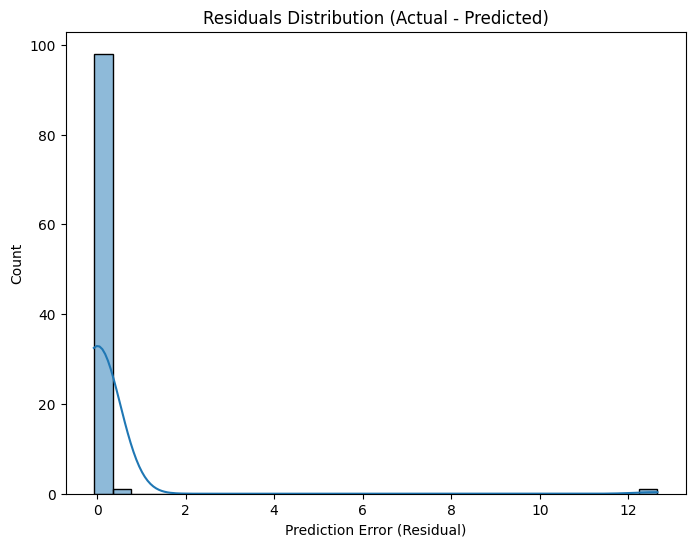

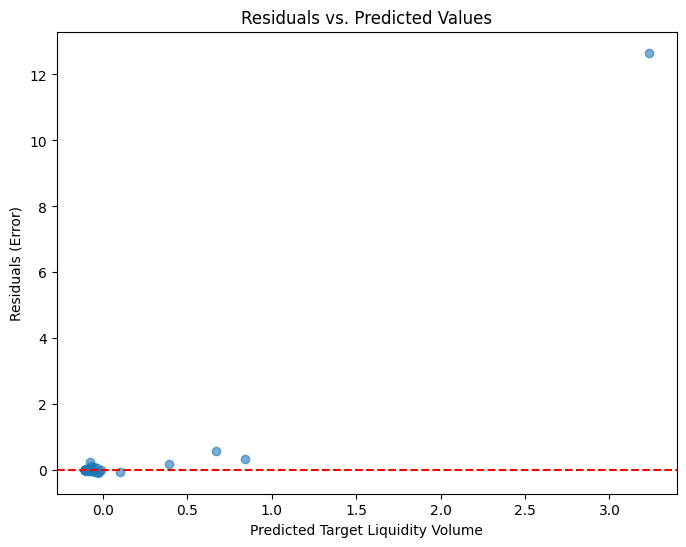

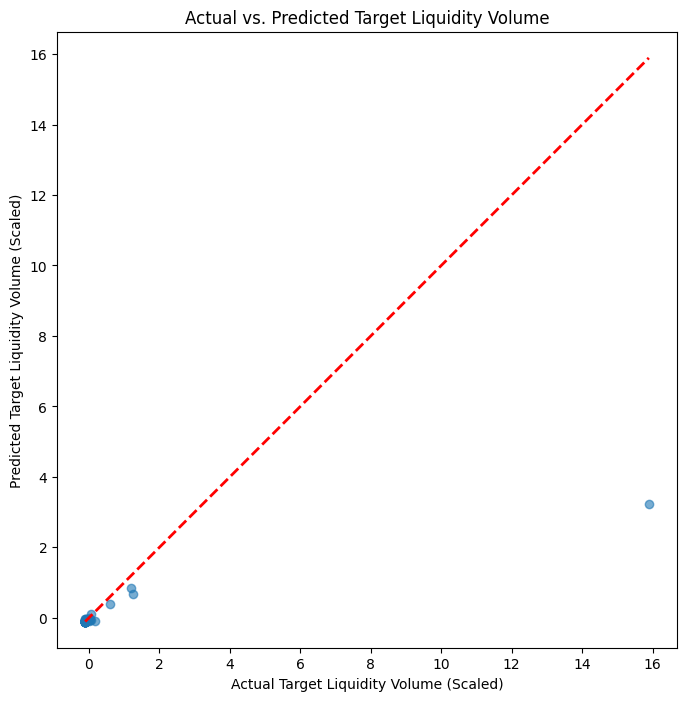

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# --- Setup: Re-run split and tuning to retrieve the best model ---
# This ensures we have the necessary X_test, Y_test, and best_rf_model objects.
df_ml = pd.read_csv('cryptocurrency_ml_ready.csv')
X = df_ml.drop(columns=['symbol', 'target_liquidity_volume'])
Y = df_ml['target_liquidity_volume']
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

# Define Hyperparameter Grid (reduced for brevity, if tuning was extensive)
param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [10, 30],
    'min_samples_split': [2, 10],
}
rf = RandomForestRegressor(random_state=42)
random_search = RandomizedSearchCV(
    estimator=rf, param_distributions=param_dist, n_iter=5, # n_iter reduced for quick re-run
    scoring='neg_mean_squared_error', cv=3, random_state=42, n_jobs=-1
)
random_search.fit(X_train, Y_train)
best_rf_model = random_search.best_estimator_
# --- End Setup ---


# 1. Prediction on Unseen Data (Test Set)
Y_pred = best_rf_model.predict(X_test)

print("\n--- Model Validation: Metrics on Unseen Data ---")
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_pred)
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2) Score: {r2:.4f}")

# 2. Residual Analysis: Check for Bias

# Calculate Residuals (Error = Actual - Predicted)
residuals = Y_test - Y_pred

# Plot 2a: Residuals Distribution
# Ideally, residuals should be normally distributed around zero.
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True, bins=30)
plt.title('Residuals Distribution (Actual - Predicted)')
plt.xlabel('Prediction Error (Residual)')
plt.savefig('residuals_distribution.png')
plt.show()

# Plot 2b: Residuals vs. Predicted Values
# Look for a random scatter, no patterns (e.g., a cone shape or curvature).
plt.figure(figsize=(8, 6))
plt.scatter(Y_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Predicted Values')
plt.xlabel('Predicted Target Liquidity Volume')
plt.ylabel('Residuals (Error)')
plt.savefig('residuals_vs_predicted.png')
plt.show()

# 3. Visualizing Predictions vs. Actuals

# Plot 3: Actual vs. Predicted Values
# Ideally, points should fall close to the 45-degree line (y=x).
plt.figure(figsize=(8, 8))
plt.scatter(Y_test, Y_pred, alpha=0.6)
# Plot the ideal prediction line (y=x)
min_val = min(Y_test.min(), Y_pred.min())
max_val = max(Y_test.max(), Y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
plt.title('Actual vs. Predicted Target Liquidity Volume')
plt.xlabel('Actual Target Liquidity Volume (Scaled)')
plt.ylabel('Predicted Target Liquidity Volume (Scaled)')
plt.axis('equal') # Ensure the scale is the same for both axes
plt.savefig('actual_vs_predicted.png')
plt.show()